In [2]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

from imblearn.over_sampling import SMOTE

In [3]:
# =========================
# 2. Load dataset
# =========================
df = pd.read_csv(r"C:\Users\20130\Downloads\Burnout_Data\student_lifestyle_100k.csv")

In [4]:
# =========================
# 3. Use first 10k rows (or random if you prefer)
# =========================
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

In [5]:
# =========================
# 4. Features / target
# =========================
X = df.drop(columns=["Depression", "Student_ID"])
y = df["Depression"].astype(int)

In [6]:
# =========================
# 5. Column types
# =========================
categorical_cols = ["Gender", "Department"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [7]:
# =========================
# 6. Preprocessing
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [8]:
# =========================
# 7. Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [9]:
# =========================
# 8. Apply preprocessing FIRST
# =========================
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [10]:
# =========================
# 9. SMOTE (fix imbalance)
# =========================
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)


In [11]:
# =========================
# 10. WKNN Model
# =========================
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

knn.fit(X_train_bal, y_train_bal)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [12]:
# =========================
# 11. Predictions
# =========================
y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

# Optional: threshold tuning (improves recall)
y_pred_thresh = (y_prob > 0.3).astype(int)

In [13]:
# =========================
# 12. Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

# Optional: threshold-based evaluation (better for imbalance)
print("\n--- Threshold 0.3 Results ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))

Accuracy: 0.7263333333333334

Confusion Matrix:
 [[2080  623]
 [ 198   99]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.84      2703
           1       0.14      0.33      0.19       297

    accuracy                           0.73      3000
   macro avg       0.53      0.55      0.51      3000
weighted avg       0.84      0.73      0.77      3000


ROC-AUC: 0.5586628400168911

--- Threshold 0.3 Results ---
Confusion Matrix:
 [[1832  871]
 [ 172  125]]
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      2703
           1       0.13      0.42      0.19       297

    accuracy                           0.65      3000
   macro avg       0.52      0.55      0.49      3000
weighted avg       0.84      0.65      0.72      3000



In [14]:
best_k = 0
best_score = 0

for k in range(3, 21, 2):  # only odd K
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )
    
    # train on SMOTE-balanced data
    knn.fit(X_train_bal, y_train_bal)
    
    # evaluate on original test set
    score = knn.score(X_test_scaled, y_test)
    
    print(f"K={k}, Accuracy={score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nBest K: {best_k} with accuracy {best_score:.4f}")

K=3, Accuracy=0.7263
K=5, Accuracy=0.6867
K=7, Accuracy=0.6547
K=9, Accuracy=0.6307
K=11, Accuracy=0.6173
K=13, Accuracy=0.6083
K=15, Accuracy=0.6017
K=17, Accuracy=0.5970
K=19, Accuracy=0.5900

Best K: 3 with accuracy 0.7263


In [15]:
# =========================
# Random Test Case (correct for SMOTE WKNN)
# =========================

import numpy as np

random_index = np.random.randint(0, len(X_test_scaled))

sample = X_test_scaled[random_index].reshape(1, -1)  # must be 2D for sklearn
actual = y_test.iloc[random_index]

prediction = knn.predict(sample)[0]

print("Random Test Case (scaled features):")
print(sample)

print("\nActual:", actual)
print("Predicted:", prediction)

label = "Depressed" if prediction == 1 else "Not Depressed"
print("Prediction Label:", label)

Random Test Case (scaled features):
[[-0.00891096 -0.34599038 -1.39359509  0.73898375  1.88802185  0.39212397
  -0.10038096  1.          0.          0.          0.          0.
   1.          0.        ]]

Actual: 0
Predicted: 0
Prediction Label: Not Depressed


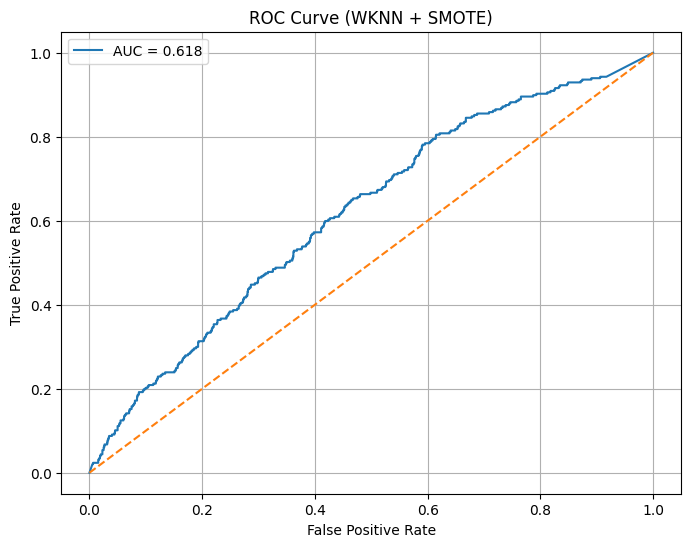

In [16]:
# =========================
# Probability predictions
# =========================
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

# =========================
# ROC values
# =========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# =========================
# AUC score
# =========================
roc_auc = auc(fpr, tpr)

# =========================
# Plot ROC curve
# =========================
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (WKNN + SMOTE)")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test, y_prob))

[[2080  623]
 [ 198   99]]
0.6184673221299193
